<a id="top"></a>
<div class="list-group" id="list-tab" role="tablist">
<h1 class="list-group-item list-group-item-action active" data-toggle="list" style='background:#005097; border:0' role="tab" aria-controls="home"><center>Inferência Estatística (GCC1625) - Trabalho 2</center></h1>

- Nome completo: Lucas Teixeira dos Santos
- [Link para vídeo](<https://youtu.be/Sz6I_95ocoo>)

# Importação das bibliotecas

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (
    shapiro,
    normaltest,
    levene,
    ttest_rel,
    ttest_ind,
    f_oneway,
    chi2_contingency
)
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# (1) Um estilo diferente ajuda?

(i) Os procedimentos paramétricos de testes de hipóteses sobre duas amostras que estudamos em nosso curso presumem que as amostras a serem usadas são provenientes de uma distribuição aproximadamente normal. Como os dados são pareados, verifique a hipótese de normalidade para a distribuição das diferenças entre as pontuações obtidas com os tacos originais e com os tacos experimentais. Para isso, use um nível de significância igual a 5%

Como os dados são pareados, devemos analisar a distribuição das diferenças entre os valores obtidos com os tacos originais e os tacos experimentais.

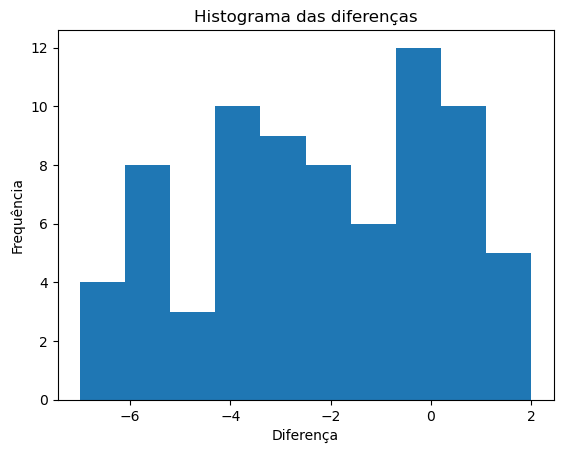

In [38]:
df = pd.read_csv('../data/golfe.csv', sep=';')
df.head()

df['diferenca'] = df['New Score '] - df['Old Score']

df['diferenca'].describe()

# Histograma das diferenças

plt.hist(df['diferenca'], bins=10)
plt.title('Histograma das diferenças')
plt.xlabel('Diferença')
plt.ylabel('Frequência')
plt.show()

In [39]:
# Teste de Shapiro-Wilk

# Hipóteses:

# H0: As diferenças seguem distribuição normal
# Ha: As diferenças não seguem distribuição normal

stat, p = stats.shapiro(df['diferenca'])

print('Estatística:', stat)
print('p-valor:', p)

alpha = 0.05

if p > alpha:
    print('Não rejeitamos H0: os dados podem ser considerados normais.')
else:
    print('Rejeitamos H0: os dados não seguem normalidade.')

Estatística: 0.940557931997127
p-valor: 0.0015661811277107834
Rejeitamos H0: os dados não seguem normalidade.


Análise

Existem evidências estatísticas suficientes para concluir que os dados não seguem distribuição normal. Assim, a suposição de normalidade necessária para aplicação direta de testes paramétricos não é satisfeita para essa amostra.

(ii) Agora, aplique o teste de hipóteses propriamente dito. Apresente e descreva claramente a aplicação dos quatro passos do procedimento. Repare que a variância da população não é conhecida. Sendo assim, certifique-se de usar o teste de hipóteses adequado para essa situação. Apresente sua análise para o nível de significância igual a 1%.

Como:

as amostras são pareadas, a variância populacional é desconhecida e assumimos normalidade.

utilizamos o teste t pareado.

In [40]:
# Passo 1 — Hipóteses

# Queremos verificar se o novo taco melhora o desempenho.

# H0: μd = 0
# Ha: μd < 0

# Onde μd representa a média das diferenças:

# μd = média(New Score − Old Score)

# Valores positivos indicam melhora com os tacos experimentais.

# Passo 2 — Estatística de teste

stat, p = stats.ttest_rel(df['New Score '], df['Old Score'])

print('t:', stat)
print('p-valor bilateral:', p)

# Como o teste desejado é unilateral à esquerda:

p_unilateral = p / 2
print('p-valor unilateral:', p_unilateral)

# Passo 3 — Nível de significância

alpha=0.01

# Passo 4 — Decisão

if  p_unilateral > alpha:
    print('Não rejeitamos H0.')
else:
    print('Rejeitamos H0.')

t: -6.925279320784546
p-valor bilateral: 1.3542654263416922e-09
p-valor unilateral: 6.771327131708461e-10
Rejeitamos H0.


Analise

Concluímos que existem evidências estatísticas muito fortes de que o novo estilo de taco melhora o desempenho dos jogadores.

# (2) Transmissões: automática versus manual

(i) Realize uma análise gráfica exploratória comparando o consumo médio de combustível dos dois grupos de veículos. Utilize ao menos dois tipos de gráfico (como boxplots e histogramas sobrepostos) e comente os padrões observados

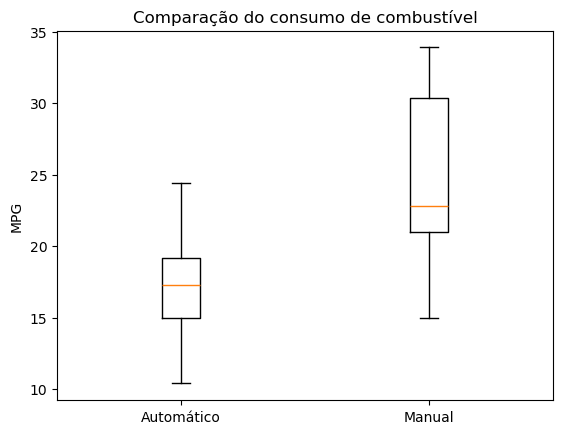

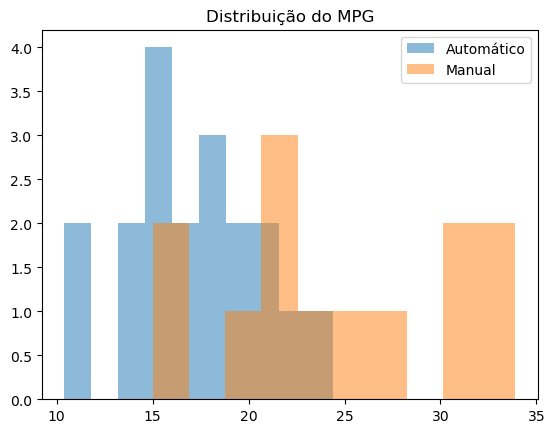

In [54]:
df = pd.read_csv('../data/mtcars.csv')
df.head()

# Separação dos grupos

automatico = df[df['am'] == 0]['mpg']
manual = df[df['am'] == 1]['mpg']

# Análise gráfica exploratória

# Boxplot

plt.boxplot([automatico, manual], tick_labels=['Automático', 'Manual'])
plt.title('Comparação do consumo de combustível')
plt.ylabel('MPG')
plt.show()

# Histogramas

plt.hist(automatico, alpha=0.5, label='Automático')
plt.hist(manual, alpha=0.5, label='Manual')
plt.legend()
plt.title('Distribuição do MPG')
plt.show()

Análise

Os gráficos indicam que os veículos manuais tendem a apresentar valores de mpg maiores que os veículos automáticos.

Além disso:

a mediana dos carros manuais parece superior, a distribuição dos manuais está deslocada para valores maiores de mpg e existe alguma sobreposição entre os grupos, mas a diferença visual parece relevante.

(ii) Os procedimentos paramétricos de testes de hipóteses sobre duas amostras que estudamos em nosso curso presumem que as amostras a serem usadas são provenientes de uma distribuição aproximadamente normal. Para cada uma das amostras fornecidas, verifique essa hipótese usando dois dos testes de normalidades que estudamos no curso. Para isso, use um nível de significância igual a 5%.

Vamos utilizar:

- Shapiro-Wilk
- D’Agostino-Pearson

In [55]:
# Hipóteses

# H0: os dados seguem distribuição normal.
# Ha: os dados não seguem distribuição normal.

# Shapiro-Wilk

print(stats.shapiro(automatico))
print(stats.shapiro(manual))

# D’Agostino-Pearson

print(stats.normaltest(automatico))
print(stats.normaltest(manual))

ShapiroResult(statistic=np.float64(0.9767742647710409), pvalue=np.float64(0.8987357901905731))
ShapiroResult(statistic=np.float64(0.9458036604933976), pvalue=np.float64(0.536272885248448))
NormaltestResult(statistic=np.float64(0.026123280859505056), pvalue=np.float64(0.9870232926051986))
NormaltestResult(statistic=np.float64(1.3447018612988142), pvalue=np.float64(0.5105069993746321))


Conclusão

Como os valores sao maiores que 0,05, não rejeitamos H0 e consideramos plausível a hipótese de normalidade.

(iii) Presumindo que os dados da coluna mpg seguem a distribuição normal, determine um intervalo de confiança no nível 95% da diferença entre as médias dos modelos de carros que possuem transmissão automática e os que possuem transmissão manual. Assuma variâncias populacionais desconhecidas e não necessariamente iguais

Como:

- as amostras são independentes
- as variâncias são desconhecidas
- as variâncias não são necessariamente iguais

utilizamos o intervalo baseado no teste t de Welch.

In [56]:
mean_diff = manual.mean() - automatico.mean()

s1 = manual.var(ddof=1)
s2 = automatico.var(ddof=1)

n1 = len(manual)
n2 = len(automatico)

se = np.sqrt(s1/n1 + s2/n2)

# graus de liberdade de Welch
num = (s1/n1 + s2/n2)**2

den = ((s1/n1)**2)/(n1-1) + ((s2/n2)**2)/(n2-1)

df = num/den

# valor crítico
critico = stats.t.ppf(0.975, df)

margem = critico * se

ic_inf = mean_diff - margem
ic_sup = mean_diff + margem

print(ic_inf, ic_sup)

3.2096841874699544 11.280194355040159


Analise

Isso significa que, com 95% de confiança, a diferença verdadeira entre as médias populacionais de mpg está entre aproximadamente 3.21 e 11.28 milhas por galão.

Como todo o intervalo é positivo e não contém o valor zero, os resultados fornecem evidências de que carros com transmissão manual possuem, em média, maior eficiência de combustível do que carros com transmissão automática.

Além disso, o fato de o intervalo não incluir zero sugere que a diferença entre os grupos é estatisticamente significativa ao nível de 5%.

(iv) Suponha que, ao analisar os dados fornecidos, alguém levantou a alegação de que carros automáticos e manuais não apresentam a mesma eficiência relativa a consumo de combustível. Em particular, existe a suspeita de que carros com transmissão manual apresentam, em média, maior valor de mpg do que carros com transmissão automática. Aplique um teste de hipóteses para verificar essa suspeita. Apresente e descreva claramente a aplicação dos quatro passos do procedimento. Repare que são fornecidas duas amostras independentes. Sendo assim, certifique-se de usar o teste de hipóteses adequado para essa situação. Apresente sua análise para o nível de significância igual a 5%. Assuma variâncias populacionais desconhecidas e não necessariamente iguais.

In [ ]:
# Passo 1 — Hipóteses


# H0: μmanual <= uautomatico
# Ha: μmanual > uautomatico

# Passo 2 — Estatística de teste

# Como:

# as amostras são independentes
# as variâncias são desconhecidas
# as variâncias não são necessariamente iguais

# utilizamos o:

# t-teste de Welch

stat, p = stats.ttest_ind(manual, automatico, equal_var=False)

print('t:', stat)
print('p bilateral:', p)

# Como o teste é unilateral à direita:

p_unilateral = p / 2
print('p unilateral:', p_unilateral)

# Passo 3 — Nível de significância

alpha=0.05

# Passo 4 — Decisão

if  p_unilateral > alpha:
    print('Não rejeitamos H0.')
else:
    print('Rejeitamos H0.')

t: 3.767123145144923
p bilateral: 0.0013736383330710362
p unilateral: 0.0006868191665355181
Rejeitamos H0.


Analise

Concluímos que existem evidências estatísticas suficientes para afirmar que carros com transmissão manual possuem, em média, maior eficiência de combustível do que carros com transmissão automática.

# (3) Teste ANOVA

### 3.1 Situação-problema I

(i) Como condição clássica de aplicabilidade do ANOVA estudada em aula, verifique se as amostras podem ser consideradas aproximadamente normais e se há homogeneidade das variâncias entre os grupos. Para isso, aplique testes de normalidade aos grupos e, em seguida, utilize o teste de Levene.

In [ ]:
# Organização dos dados

compactos = np.array([
20,25,25,20,22,22,24,26,20,24,24,23,20,23,21,21
])

medios = np.array([
18,19,22,22,19,16,21,21,21,20,17,18,18,17,19,19,
18,21,23,19,22,20
])

grandes = np.array([
19,16,16,17,20,20,20,18,18,19,19,15,18,
17,15,18,17,18,18,17
])

# Hipoteses

# H0: os dados seguem distribuição normal
# Ha: os dados não seguem distribuição normal

# Verificação das condições

# Normalidade

print(stats.shapiro(compactos))
print(stats.shapiro(medios))
print(stats.shapiro(grandes))

# Homogeneidade das variâncias

stats.levene(compactos, medios, grandes)

ShapiroResult(statistic=np.float64(0.9143226544741284), pvalue=np.float64(0.13663509547088665))
ShapiroResult(statistic=np.float64(0.9590022957654518), pvalue=np.float64(0.46937828838635787))
ShapiroResult(statistic=np.float64(0.9363201897402933), pvalue=np.float64(0.20412792326477264))


LeveneResult(statistic=np.float64(1.5446135623790822), pvalue=np.float64(0.2225076820121474))

Analise

Shapiro:

Como todos os p-valores são maiores que 0,05, não rejeitamos H0 para nenhum dos grupos.

Assim, não existem evidências estatísticas de violação da normalidade, indicando que a suposição de distribuição aproximadamente normal é plausível para os três grupos.

Levene:

não rejeitamos H0. Portanto, não existem evidências de diferença significativa entre as variâncias dos grupos, indicando que a condição de homocedasticidade pode ser considerada satisfeita.

(ii) Agora que você verificou as condições aplicabilidade do ANOVA, aplique esse teste para verificar a hipótese nula de que as três populações têm médias estatisticamente iguais. Declare as hipóteses nula e alternativa. A seguir, descreva sua conclusão. Use nível de significância de 5%.

In [59]:
# Hipóteses da ANOVA

# H0:μcompactos=μmedios=μgrandes
# Ha:pelo menos uma media difere

# Aplicação da ANOVA

f_stat, p = stats.f_oneway(compactos, medios, grandes)

print('F:', f_stat)
print('p-valor:', p)

# Decisão

# Se p≤0.05: rejeitamos H0.
# Se p>0.05: não rejeitamos H0.

F: 30.64323773770957
p-valor: 1.1426698001297829e-09


Analise

Concluímos que existem diferenças estatisticamente significativas entre pelo menos uma das médias de MPG dos grupos analisados.

Como a ANOVA apenas indica a existência de diferença, é necessário aplicar o teste de Tukey para identificar especificamente quais grupos diferem entre si.

In [60]:
valores = np.concatenate([compactos, medios, grandes])

grupos = (
    ['Compactos'] * len(compactos) +
    ['Médios'] * len(medios) +
    ['Grandes'] * len(grandes)
)

resultado = pairwise_tukeyhsd(valores, grupos, alpha=0.05)

print(resultado)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1   group2 meandiff p-adj   lower   upper  reject
--------------------------------------------------------
Compactos Grandes    -4.75    0.0 -6.2165 -3.2835   True
Compactos  Médios  -2.9545    0.0 -4.3911  -1.518   True
  Grandes  Médios   1.7955 0.0063  0.4446  3.1463   True
--------------------------------------------------------


Como todos os p-valores foram menores que 0,05, conclui-se que todas as comparações apresentaram diferenças estatisticamente significativas.

De forma geral:

- veículos compactos apresentaram a maior média de MPG
- veículos médios apresentaram valores intermediários
- veículos grandes/vans apresentaram a menor média de MPG.

Isso indica que o tipo/categoria do veículo influencia significativamente a eficiência média de combustível.

### 3.2 Situação-problema II

No arquivo data/data9.xls do repositório GitHub do curso, você encontra dados que registram os custos dos materiais (livro didático, manual de solução, taxas de laboratório e assim por diante) em cada um dos dez cursos diferentes em cada um dos três assuntos diferentes,
química, ciência da computação e matemática. Verifique, ao nível de significância de 1%, se os dados fornecem evidências suficientes para concluir que os custos médios nas três disciplinas não são todos iguais. Apresente os detalhes de aplicação de todos os quatro passos do teste de hipóteses.

In [ ]:
math = [195,129,119,122,135,210,137,199,220,149]

comp = [179,181,220,302,125,125,168,204,177,143]

chem = [105,243,208,176,132,155,97,98,105,148]

# Hipoteses

# H0: os dados seguem distribuição normal
# Ha: os dados não seguem distribuição normal

# Verificação das condições

# Normalidade

print(stats.shapiro(math))
print(stats.shapiro(comp))
print(stats.shapiro(chem))

# Homogeneidade das variâncias

stats.levene(math, comp, chem)

ShapiroResult(statistic=np.float64(0.8491317966950599), pvalue=np.float64(0.05672321488932396))
ShapiroResult(statistic=np.float64(0.8858667896531944), pvalue=np.float64(0.15226819291773847))
ShapiroResult(statistic=np.float64(0.8956866766859353), pvalue=np.float64(0.1963312314807309))


LeveneResult(statistic=np.float64(0.10335837318075675), pvalue=np.float64(0.902158804476578))

Analise

Shapiro:

Como todos os p-valores são maiores que 0,01, não rejeitamos H0 para nenhum dos grupos.

Assim, não existem evidências estatísticas de violação da normalidade, indicando que a suposição de distribuição aproximadamente normal é plausível para os três grupos.

Levene:

não rejeitamos H0. Portanto, não existem evidências de diferença significativa entre as variâncias dos grupos, indicando que a condição de homocedasticidade pode ser considerada satisfeita.

In [ ]:
# Hipóteses da ANOVA

# H0:μmath=μcomp=μchem
# Ha:pelo menos uma media difere

# Aplicação da ANOVA

f_stat, p = stats.f_oneway(math, comp, chem)

print('F:', f_stat)
print('p-valor:', p)

# Decisão

# Se p≤0.01: rejeitamos H0.
# Se p>0.01: não rejeitamos H0.

F: 1.418046917087027
p-valor: 0.2596535697144005


Analise

Não existem evidências estatísticas suficientes para afirmar que as médias dos custos dos cursos diferem significativamente entre os grupos MATH, COMP e CHEM.

Isso indica que, com base nos dados analisados, os custos médios dos cursos podem ser considerados estatisticamente semelhantes entre as três categorias.

Como a ANOVA não foi significativa, não é necessário aplicar o teste de Tukey.

# (4)  Testes Qui-quadrado

(i) a tabela de contingência observada;

In [63]:
df = pd.read_csv('../data/treatment.csv')

contingencia = pd.crosstab(
    df['treatment'],
    df['improvement']
)

print(contingencia)

improvement  improved  not-improved
treatment                          
not-treated        26            29
treated            35            15


(ii) as hipóteses nula e alternativa do teste;

As hipóteses do teste qui-quadrado de independência são:

- H0:as variaveis sao independentes
- Ha:as variaveis sao dependentes

Ou seja:

- H0: o tratamento não possui associação com a melhora;
- Ha: existe associação entre tratamento e melhora.

(iii) o valor da estatística de teste qui-quadrado;

In [64]:
chi2, p, gl, esperadas = chi2_contingency(contingencia)

print('Qui-quadrado:', chi2)

Qui-quadrado: 4.6625668947297125


(iv) os graus de liberdade;

In [65]:
print('Graus de liberdade:', gl)

Graus de liberdade: 1


(v) o valor-p;

In [66]:
print('p-valor:', p)

p-valor: 0.030827072412198585


(vi) sua conclusão, interpretada no contexto do problema.

Analise

Com base nos resultados do teste qui-quadrado, rejeitamos a hipótese nula de independência entre as variáveis. (p<0,05)

Assim, existem evidências estatísticas suficientes para concluir que o tratamento aplicado está associado à melhora dos pacientes.

Na prática, isso indica que pacientes que receberam o tratamento apresentaram comportamento de melhora diferente dos pacientes que não receberam tratamento, sugerindo que o tratamento pode ter influência nos resultados observados.